In [1]:
# ============================================================
# Section 1: Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# ============================================================
# Section 2: Load and Merge Data
# ============================================================
collision_url = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-collision-provisional-2025.csv"
vehicle_url   = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-vehicle-provisional-2025.csv"
casualty_url  = "https://raw.githubusercontent.com/siyi-w/DSSS/main/as/dft-road-casualty-statistics-casualty-provisional-2025.csv"

df_collision = pd.read_csv(collision_url)
df_vehicle   = pd.read_csv(vehicle_url)
df_casualty  = pd.read_csv(casualty_url)

print(f"Collision records : {len(df_collision):,}")
print(f"Vehicle records   : {len(df_vehicle):,}")
print(f"Casualty records  : {len(df_casualty):,}")

Collision records : 48,472
Vehicle records   : 87,805
Casualty records  : 60,991


In [19]:
# ============================================================
# Section 3: Data Cleaning and Filtering
# ============================================================

# --- 3.1 Filter London (Metropolitan Police=1, City of London=2) ---
df_london = df_collision[df_collision['police_force'].isin([1, 2])].copy()
print(f"London collisions: {len(df_london):,}")

# --- 3.2 Filter two-wheelers ---
two_wheeler_types = [1, 2, 3, 4, 5, 23]
df_tw_vehicle = df_vehicle[df_vehicle['vehicle_type'].isin(two_wheeler_types)]
tw_ids = df_tw_vehicle['collision_index'].unique()

df_tw = df_london[df_london['collision_index'].isin(tw_ids)].copy()
print(f"London two-wheeler collisions: {len(df_tw):,}")

# --- 3.3 Binary severity target ---
df_tw['severity_binary'] = (df_tw['collision_severity'] <= 2).astype(int)
print(f"\nSeverity distribution:")
print(df_tw['severity_binary'].value_counts(normalize=True).round(3))

# --- 3.4 Time features ---
df_tw['date'] = pd.to_datetime(df_tw['date'], dayfirst=True)
df_tw['hour'] = df_tw['time'].str[:2].astype(float)
df_tw['is_weekend'] = (df_tw['day_of_week'] >= 5).astype(int)

# --- 3.5 Final modelling dataset ---
features = ['hour', 'is_weekend',
            'road_type', 'speed_limit', 'junction_detail',
            'light_conditions', 'weather_conditions',
            'road_surface_conditions', 'urban_or_rural_area',
            'number_of_vehicles', 'number_of_casualties']

df_model = df_tw[features + ['severity_binary']].dropna()
print(f"\nFinal modelling dataset: {len(df_model):,} rows")
print(f"Serious/Fatal rate: {df_model['severity_binary'].mean():.1%}")

London collisions: 10,062
London two-wheeler collisions: 4,966

Severity distribution:
severity_binary
0    0.796
1    0.204
Name: proportion, dtype: float64

Final modelling dataset: 4,966 rows
Serious/Fatal rate: 20.4%


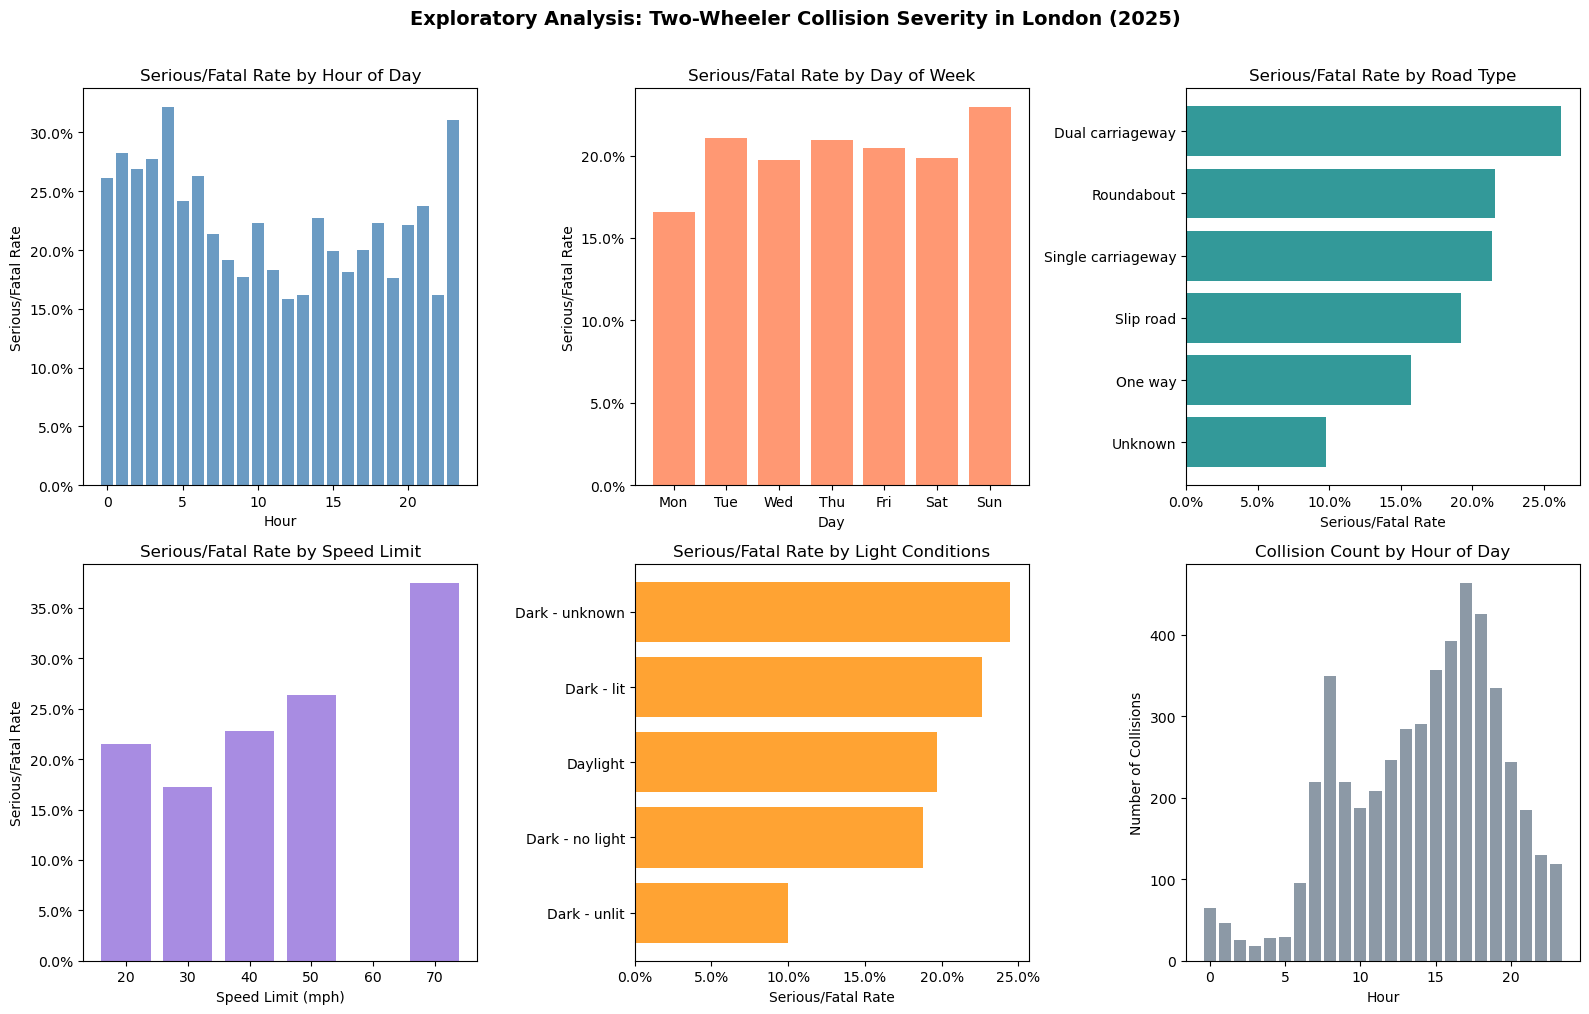

In [21]:
# ============================================================
# Section 4: EDA + Correlation Heatmap
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Analysis: Two-Wheeler Collision Severity in London (2025)',
             fontsize=14, fontweight='bold', y=1.01)

# -- 4.1 Severity rate by hour --
hourly = df_model.groupby('hour')['severity_binary'].mean().reset_index()
axes[0,0].bar(hourly['hour'], hourly['severity_binary'], color='steelblue', alpha=0.8)
axes[0,0].set_title('Serious/Fatal Rate by Hour of Day')
axes[0,0].set_xlabel('Hour'); axes[0,0].set_ylabel('Serious/Fatal Rate')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.2 Severity rate by day of week --
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df_tw.groupby('day_of_week')['severity_binary'].mean()
axes[0,1].bar(day_labels, daily.values, color='coral', alpha=0.8)
axes[0,1].set_title('Serious/Fatal Rate by Day of Week')
axes[0,1].set_xlabel('Day'); axes[0,1].set_ylabel('Serious/Fatal Rate')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.3 Severity rate by road type --
road_labels = {1:'Roundabout', 2:'One way', 3:'Dual carriageway',
               6:'Single carriageway', 7:'Slip road', 9:'Unknown'}
df_model['road_type_label'] = df_model['road_type'].map(road_labels).fillna('Other')
road = df_model.groupby('road_type_label')['severity_binary'].mean().sort_values(ascending=True)
axes[0,2].barh(road.index, road.values, color='teal', alpha=0.8)
axes[0,2].set_title('Serious/Fatal Rate by Road Type')
axes[0,2].set_xlabel('Serious/Fatal Rate')
axes[0,2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.4 Severity rate by speed limit --
speed = df_model.groupby('speed_limit')['severity_binary'].mean().reset_index()
axes[1,0].bar(speed['speed_limit'].astype(str), speed['severity_binary'],
              color='mediumpurple', alpha=0.8)
axes[1,0].set_title('Serious/Fatal Rate by Speed Limit')
axes[1,0].set_xlabel('Speed Limit (mph)'); axes[1,0].set_ylabel('Serious/Fatal Rate')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.5 Severity rate by light conditions --
light_labels = {1:'Daylight', 4:'Dark - lit', 5:'Dark - unlit', 6:'Dark - no light', 7:'Dark - unknown'}
df_model['light_label'] = df_model['light_conditions'].map(light_labels).fillna('Other')
light = df_model.groupby('light_label')['severity_binary'].mean().sort_values(ascending=True)
axes[1,1].barh(light.index, light.values, color='darkorange', alpha=0.8)
axes[1,1].set_title('Serious/Fatal Rate by Light Conditions')
axes[1,1].set_xlabel('Serious/Fatal Rate')
axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# -- 4.6 Collision count by hour (volume context) --
hour_count = df_model.groupby('hour').size()
axes[1,2].bar(hour_count.index, hour_count.values, color='slategray', alpha=0.8)
axes[1,2].set_title('Collision Count by Hour of Day')
axes[1,2].set_xlabel('Hour'); axes[1,2].set_ylabel('Number of Collisions')

plt.tight_layout()
plt.savefig('eda_severity.png', dpi=150, bbox_inches='tight')
plt.show()

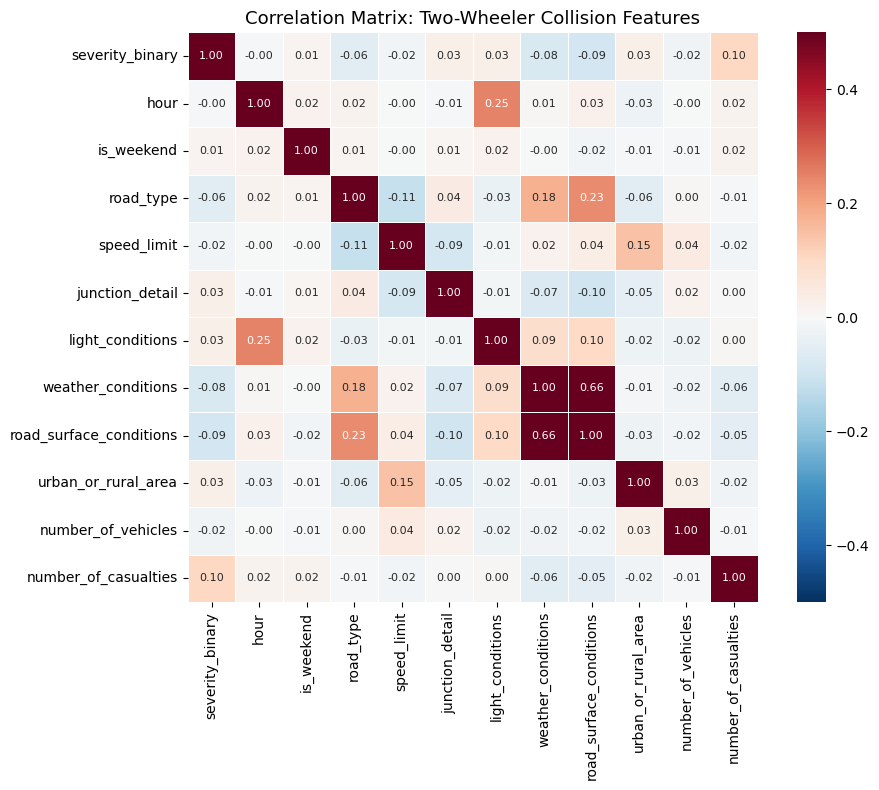


Top correlations with severity_binary:
number_of_casualties       0.104
road_surface_conditions    0.091
weather_conditions         0.080
road_type                  0.055
urban_or_rural_area        0.031
junction_detail            0.030
light_conditions           0.029
number_of_vehicles         0.021
Name: severity_binary, dtype: float64


In [22]:
# -- 4.7 Correlation Heatmap --
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['severity_binary', 'hour', 'is_weekend',
             'road_type', 'speed_limit', 'junction_detail',
             'light_conditions', 'weather_conditions',
             'road_surface_conditions', 'urban_or_rural_area',
             'number_of_vehicles', 'number_of_casualties']

corr_matrix = df_model[corr_cols].corr()

sns.heatmap(corr_matrix,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})

ax.set_title('Correlation Matrix: Two-Wheeler Collision Features', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with severity_binary:")
print(corr_matrix['severity_binary'].drop('severity_binary').abs()
      .sort_values(ascending=False).head(8).round(3))

After SMOTE - Training set class distribution: {0: 3163, 1: 3163}

--- Logistic Regression ---
               precision    recall  f1-score   support

       Slight       0.82      0.55      0.66       791
Serious/Fatal       0.23      0.51      0.31       203

     accuracy                           0.54       994
    macro avg       0.52      0.53      0.49       994
 weighted avg       0.70      0.54      0.59       994

ROC-AUC: 0.557


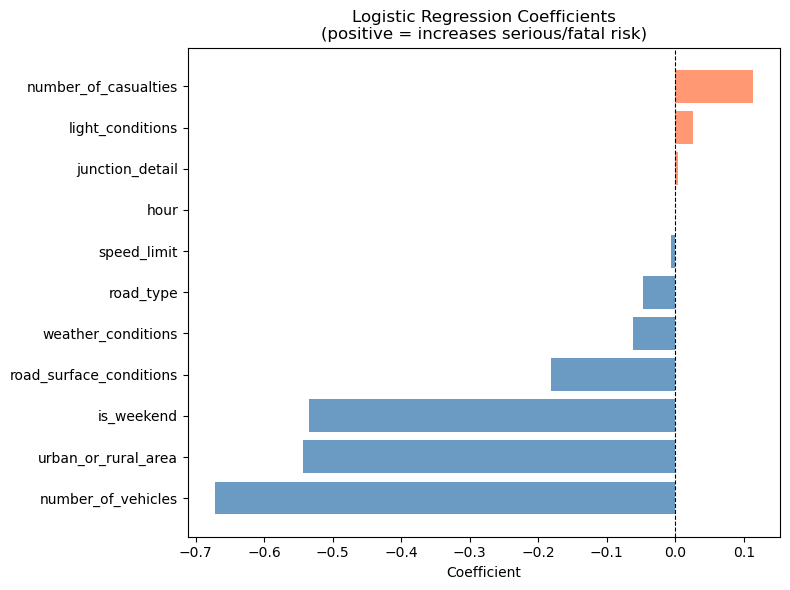

In [23]:
# ============================================================
# Section 5: Logistic Regression
# ============================================================

X = df_model[features]
y = df_model['severity_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"After SMOTE - Training set class distribution: {pd.Series(y_train_sm).value_counts().to_dict()}")

# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

# Evaluate
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# Coefficient plot
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(positive = increases serious/fatal risk)')
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

--- Random Forest ---
               precision    recall  f1-score   support

       Slight       0.81      0.77      0.79       791
Serious/Fatal       0.24      0.29      0.27       203

     accuracy                           0.67       994
    macro avg       0.53      0.53      0.53       994
 weighted avg       0.69      0.67      0.68       994

ROC-AUC: 0.570


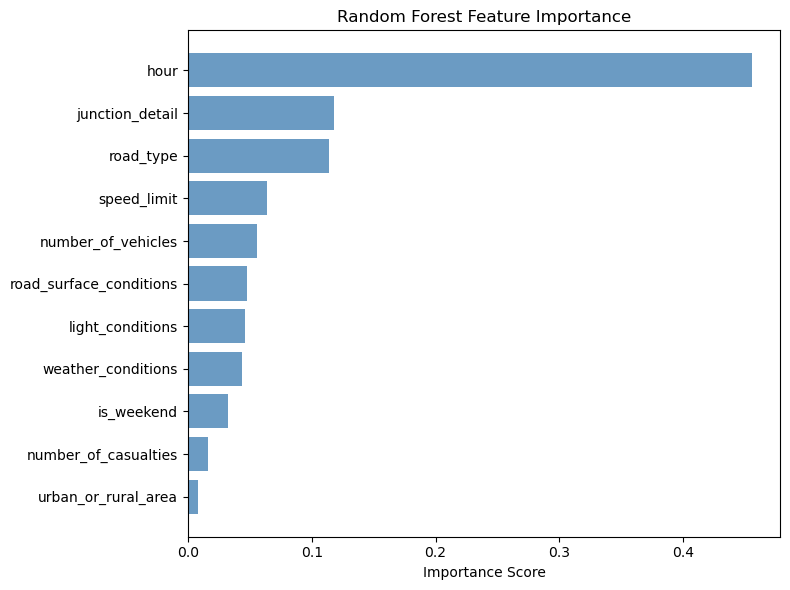

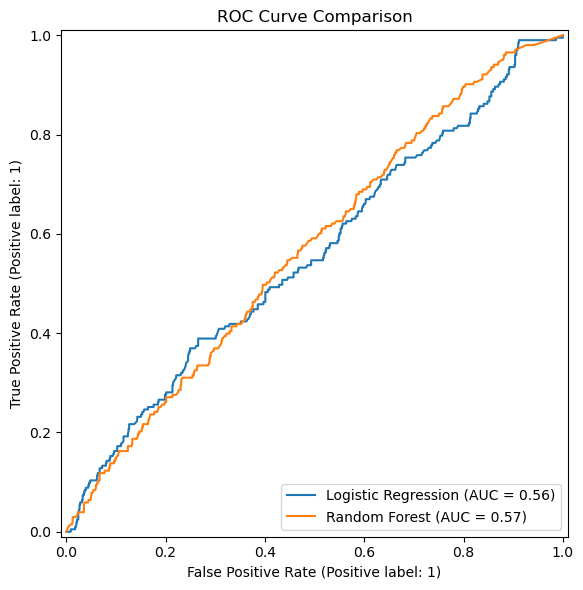

In [24]:
# ============================================================
# Section 6: Random Forest
# ============================================================

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Slight','Serious/Fatal']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")

# Feature importance plot
fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax)
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

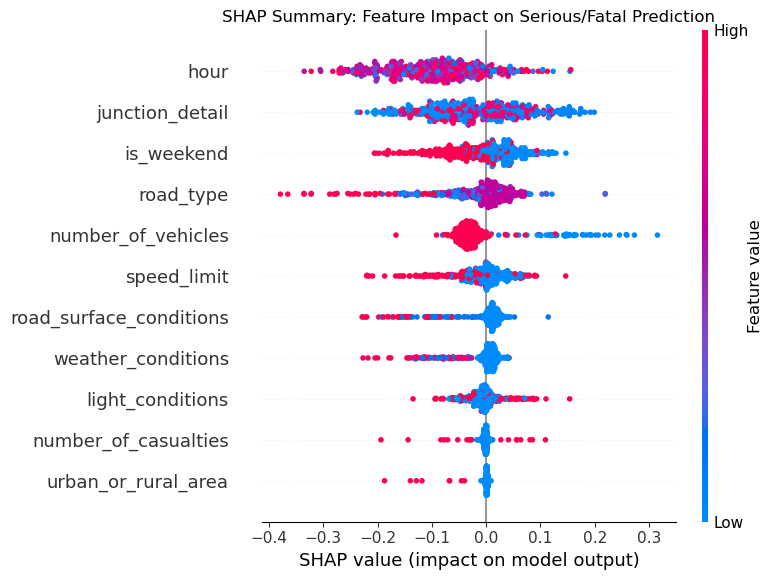

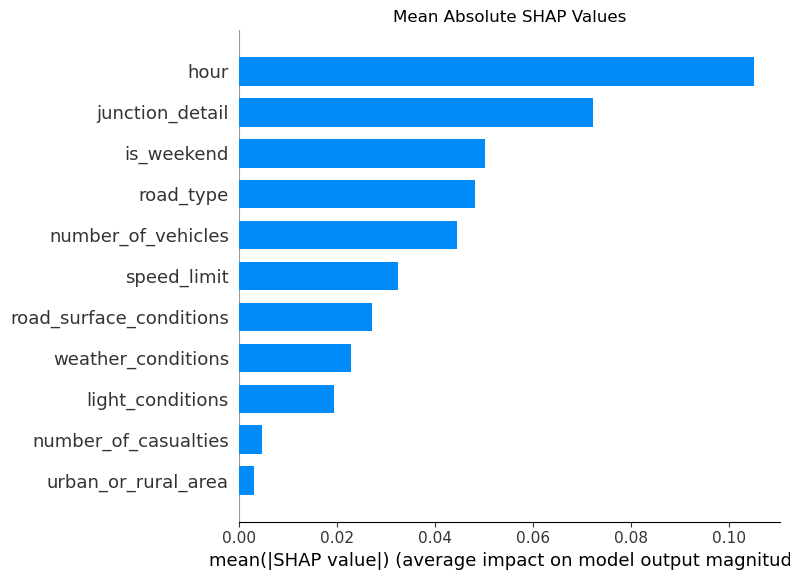

In [25]:
# ============================================================
# Section 7: SHAP Analysis
# ============================================================
# Note: shap 0.51.0 — install via: pip install shap

explainer = shap.TreeExplainer(rf)
X_test_sample = X_test.sample(500, random_state=42)  # sample for speed
shap_values = explainer.shap_values(X_test_sample)

# SHAP values for class 1 (Serious/Fatal)
shap_vals_class1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values[1]

# -- 7.1 Beeswarm summary plot --
plt.figure()
shap.summary_plot(shap_vals_class1, X_test_sample,
                  feature_names=features, show=False)
plt.title('SHAP Summary: Feature Impact on Serious/Fatal Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# -- 7.2 Mean absolute SHAP bar chart --
plt.figure()
shap.summary_plot(shap_vals_class1, X_test_sample,
                  feature_names=features, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Values')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()